# IMPLEMENTATION OF PORTFOLIO MAKING

In [8]:

from datetime import date
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from nsepy import *
import yfinance as yf

List of all the stocks in our portfolio

In [15]:
Stocks = ["RELIANCE.NS", "TCS.NS", "INFY.NS", "ITC.NS", "HDFCBANK.NS", "LT.NS", "MARUTI.NS", "WIPRO.NS", "POWERGRID.NS", "NTPC.NS"]


 Fetching the closing rates of stocks

In [16]:
pf_data = pd.DataFrame()

for a in Stocks:
    data = yf.download(tickers=a, start="2024-01-01", end="2024-12-20", interval="1d")
    pf_data[a] = data['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [17]:
pf_data

,RELIANCE.NS,TCS.NS,INFY.NS,ITC.NS,HDFCBANK.NS,LT.NS,MARUTI.NS,WIPRO.NS,POWERGRID.NS,NTPC.NS
Date,,,,,,,,,,
2024-01-01,1295.125000,3811.100098,1551.349976,468.049988,1698.099976,3525.449951,10283.299805,238.574997,238.250000,309.750000
2024-01-02,1305.849976,3783.199951,1534.400024,470.350006,1699.099976,3438.100098,10197.750000,234.600006,237.850006,306.000000
2024-01-03,1291.650024,3691.750000,1490.000000,477.250000,1672.900024,3440.350098,10077.650391,227.949997,237.050003,306.200012
2024-01-04,1298.324951,3666.800049,1512.699951,476.399994,1690.849976,3458.699951,10015.299805,226.199997,241.449997,317.100006
2024-01-05,1303.849976,3737.899902,1532.550049,473.950012,1682.199951,3521.899902,10017.000000,228.300003,241.250000,314.950012
...,...,...,...,...,...,...,...,...,...,...
2024-12-13,1272.849976,4473.899902,1999.699951,470.000000,1871.750000,3887.000000,11272.549805,309.950012,333.850006,357.149994
2024-12-16,1268.300049,4415.200195,1980.050049,470.100006,1865.199951,3877.850098,11277.000000,309.200012,335.000000,352.899994
2024-12-17,1245.300049,4328.500000,1976.599976,469.549988,1833.250000,3807.199951,11108.549805,308.850006,329.799988,349.049988


Saving the Stock data in csv file (Code commented after use)

# EDA

In [20]:
pf_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 239 entries, 2024-01-01 to 2024-12-19
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RELIANCE.NS   239 non-null    float64
 1   TCS.NS        239 non-null    float64
 2   INFY.NS       239 non-null    float64
 3   ITC.NS        239 non-null    float64
 4   HDFCBANK.NS   239 non-null    float64
 5   LT.NS         239 non-null    float64
 6   MARUTI.NS     239 non-null    float64
 7   WIPRO.NS      239 non-null    float64
 8   POWERGRID.NS  239 non-null    float64
 9   NTPC.NS       239 non-null    float64
dtypes: float64(10)
memory usage: 20.5 KB


### Plotting daily prices of all the stocks


<Figure size 640x480 with 0 Axes>

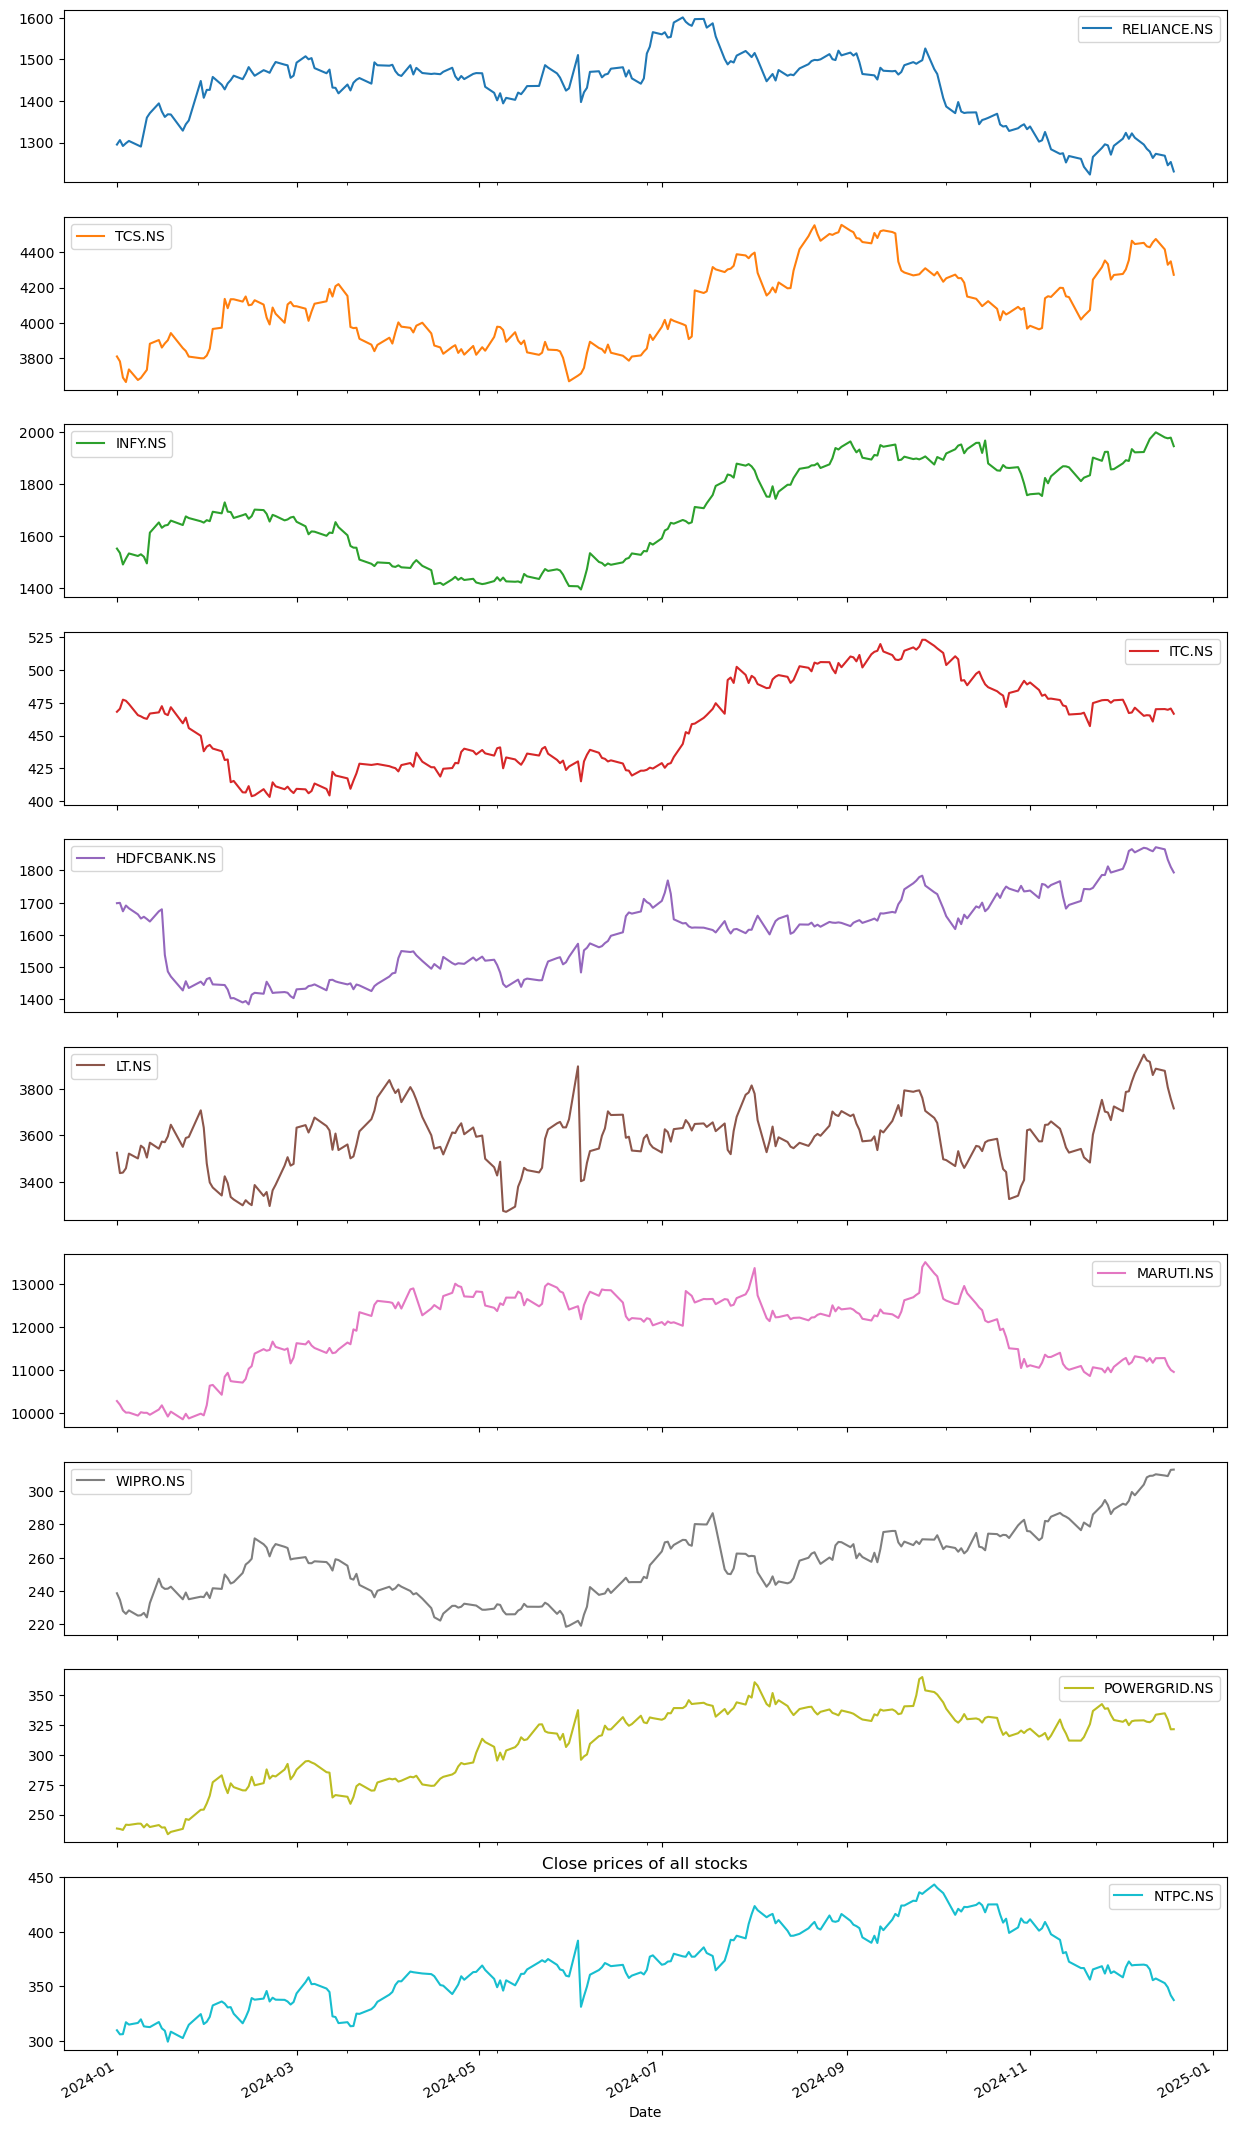

In [21]:
plt.figure()
pf_data.plot(subplots = True,figsize = (15,30))
plt.title("Close prices of all stocks")
plt.show()

### Finding Daily returns

Formulas used -> Ratio of present Day's return to Yesterday's return

In [22]:
pf_data/pf_data.shift(1)

,RELIANCE.NS,TCS.NS,INFY.NS,ITC.NS,HDFCBANK.NS,LT.NS,MARUTI.NS,WIPRO.NS,POWERGRID.NS,NTPC.NS
Date,,,,,,,,,,
2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-02,1.008281,0.992679,0.989074,1.004914,1.000589,0.975223,0.991681,0.983339,0.998321,0.987893
2024-01-03,0.989126,0.975827,0.971064,1.014670,0.984580,1.000654,0.988223,0.971654,0.996637,1.000654
2024-01-04,1.005168,0.993242,1.015235,0.998219,1.010730,1.005334,0.993813,0.992323,1.018561,1.035598
2024-01-05,1.004256,1.019390,1.013122,0.994857,0.994884,1.018273,1.000170,1.009284,0.999172,0.993220
...,...,...,...,...,...,...,...,...,...,...
2024-12-13,1.007879,1.004254,1.006392,1.020408,1.006723,1.007021,1.009416,1.002750,1.014125,1.004359
2024-12-16,0.996425,0.986880,0.990174,1.000213,0.996501,0.997646,1.000395,0.997580,1.003445,0.988100
2024-12-17,0.981865,0.980363,0.998258,0.998830,0.982870,0.981781,0.985062,0.998868,0.984478,0.989090


### In finance, we generally use logarithmic returns for analysis

In [23]:
log_returns = np.log(pf_data/pf_data.shift(1))

In [24]:
log_returns

,RELIANCE.NS,TCS.NS,INFY.NS,ITC.NS,HDFCBANK.NS,LT.NS,MARUTI.NS,WIPRO.NS,POWERGRID.NS,NTPC.NS
Date,,,,,,,,,,
2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-02,0.008247,-0.007348,-0.010986,0.004902,0.000589,-0.025089,-0.008354,-0.016802,-0.001680,-0.012180
2024-01-03,-0.010934,-0.024470,-0.029363,0.014563,-0.015540,0.000654,-0.011847,-0.028756,-0.003369,0.000653
2024-01-04,0.005154,-0.006781,0.015120,-0.001783,0.010673,0.005320,-0.006206,-0.007707,0.018391,0.034979
2024-01-05,0.004246,0.019205,0.013037,-0.005156,-0.005129,0.018108,0.000170,0.009241,-0.000829,-0.006803
...,...,...,...,...,...,...,...,...,...,...
2024-12-13,0.007848,0.004245,0.006371,0.020203,0.006701,0.006996,0.009372,0.002746,0.014026,0.004349
2024-12-16,-0.003581,-0.013207,-0.009875,0.000213,-0.003506,-0.002357,0.000395,-0.002423,0.003439,-0.011971
2024-12-17,-0.018301,-0.019832,-0.001744,-0.001171,-0.017278,-0.018387,-0.015050,-0.001133,-0.015644,-0.010970


In [25]:
log_returns.mean()

RELIANCE.NS    -0.000215
TCS.NS          0.000480
INFY.NS         0.000953
ITC.NS         -0.000013
HDFCBANK.NS     0.000230
LT.NS           0.000222
MARUTI.NS       0.000266
WIPRO.NS        0.001137
POWERGRID.NS    0.001261
NTPC.NS         0.000359
dtype: float64

Let's calculate the annual average return

In [26]:
log_returns.mean() * 250 # Stock market is open for almost 250 days in an year

RELIANCE.NS    -0.053810
TCS.NS          0.119896
INFY.NS         0.238186
ITC.NS         -0.003372
HDFCBANK.NS     0.057415
LT.NS           0.055393
MARUTI.NS       0.066499
WIPRO.NS        0.284370
POWERGRID.NS    0.315277
NTPC.NS         0.089815
dtype: float64

- We can see that Bajaj Finance stocks have the highest return while Axis Bank stocks have the lowest return

In [27]:
log_returns.std()

RELIANCE.NS     0.014556
TCS.NS          0.013289
INFY.NS         0.014569
ITC.NS          0.012258
HDFCBANK.NS     0.014350
LT.NS           0.018237
MARUTI.NS       0.014536
WIPRO.NS        0.017729
POWERGRID.NS    0.019859
NTPC.NS         0.020601
dtype: float64

In [28]:
log_returns.cov()

,RELIANCE.NS,TCS.NS,INFY.NS,ITC.NS,HDFCBANK.NS,LT.NS,MARUTI.NS,WIPRO.NS,POWERGRID.NS,NTPC.NS
RELIANCE.NS,0.000212,0.000051,0.000040,0.000054,0.000062,0.000146,0.000080,0.000097,0.000140,0.000166
TCS.NS,0.000051,0.000177,0.000135,0.000028,0.000011,0.000053,0.000037,0.000142,0.000031,0.000031
INFY.NS,0.000040,0.000135,0.000212,0.000036,0.000018,0.000053,0.000031,0.000143,0.000032,0.000030
ITC.NS,0.000054,0.000028,0.000036,0.000150,0.000032,0.000051,0.000050,0.000049,0.000030,0.000060
HDFCBANK.NS,0.000062,0.000011,0.000018,0.000032,0.000206,0.000095,0.000054,0.000050,0.000095,0.000110
LT.NS,0.000146,0.000053,0.000053,0.000051,0.000095,0.000333,0.000090,0.000103,0.000174,0.000216
MARUTI.NS,0.000080,0.000037,0.000031,0.000050,0.000054,0.000090,0.000211,0.000051,0.000084,0.000087
WIPRO.NS,0.000097,0.000142,0.000143,0.000049,0.000050,0.000103,0.000051,0.000314,0.000066,0.000075
POWERGRID.NS,0.000140,0.000031,0.000032,0.000030,0.000095,0.000174,0.000084,0.000066,0.000394,0.000294
NTPC.NS,0.000166,0.000031,0.000030,0.000060,0.000110,0.000216,0.000087,0.000075,0.000294,0.000424


In [29]:
log_returns.corr()

,RELIANCE.NS,TCS.NS,INFY.NS,ITC.NS,HDFCBANK.NS,LT.NS,MARUTI.NS,WIPRO.NS,POWERGRID.NS,NTPC.NS
RELIANCE.NS,1.000000,0.264516,0.187898,0.305432,0.299193,0.550143,0.379624,0.374372,0.485319,0.555026
TCS.NS,0.264516,1.000000,0.695088,0.169078,0.059509,0.219804,0.190469,0.601578,0.116186,0.113094
INFY.NS,0.187898,0.695088,1.000000,0.200042,0.084061,0.200123,0.147757,0.554829,0.109595,0.099398
ITC.NS,0.305432,0.169078,0.200042,1.000000,0.179622,0.226931,0.278592,0.223528,0.121226,0.236402
HDFCBANK.NS,0.299193,0.059509,0.084061,0.179622,1.000000,0.361108,0.259258,0.196628,0.333333,0.371416
LT.NS,0.550143,0.219804,0.200123,0.226931,0.361108,1.000000,0.338344,0.318852,0.480639,0.574006
MARUTI.NS,0.379624,0.190469,0.147757,0.278592,0.259258,0.338344,1.000000,0.197302,0.290764,0.291010
WIPRO.NS,0.374372,0.601578,0.554829,0.223528,0.196628,0.318852,0.197302,1.000000,0.188862,0.204283
POWERGRID.NS,0.485319,0.116186,0.109595,0.121226,0.333333,0.480639,0.290764,0.188862,1.000000,0.718309
NTPC.NS,0.555026,0.113094,0.099398,0.236402,0.371416,0.574006,0.291010,0.204283,0.718309,1.000000


### Plotting Correlation HeatMap

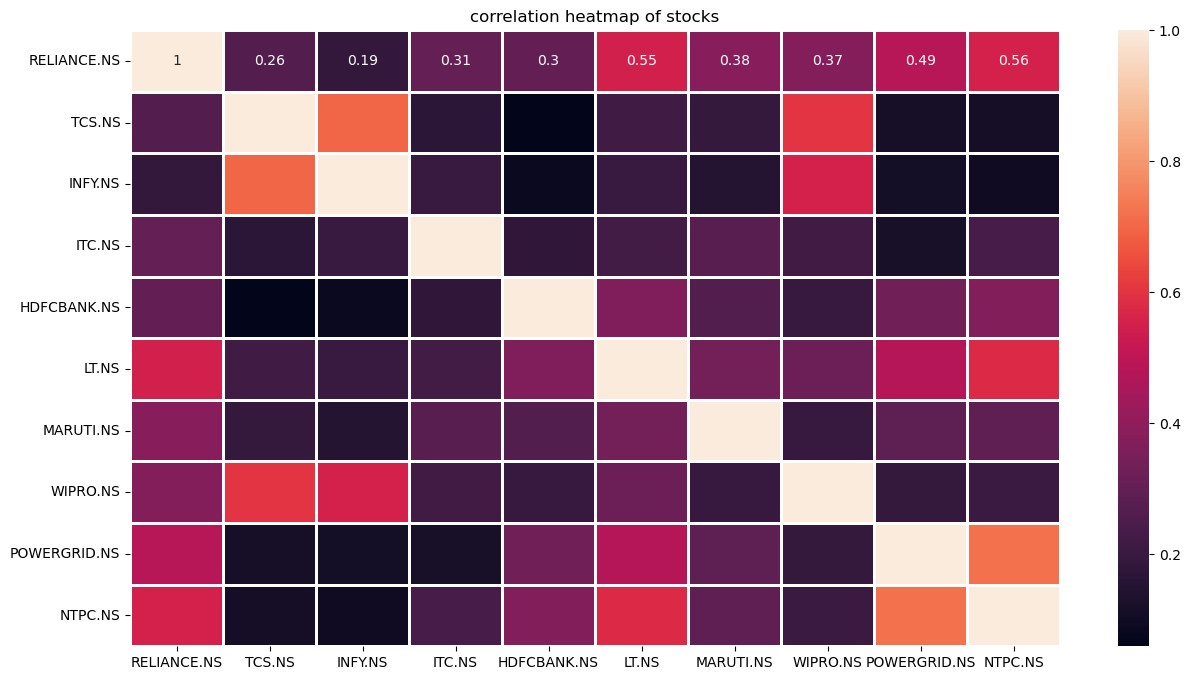

In [32]:
plt.figure(figsize=(15,8))
sns.heatmap(log_returns.corr(),linecolor='white',linewidths=1,annot=True)
plt.title("correlation heatmap of stocks")
plt.show()

### Using heatmap to find strongly positive or strongly negative correlated stocks

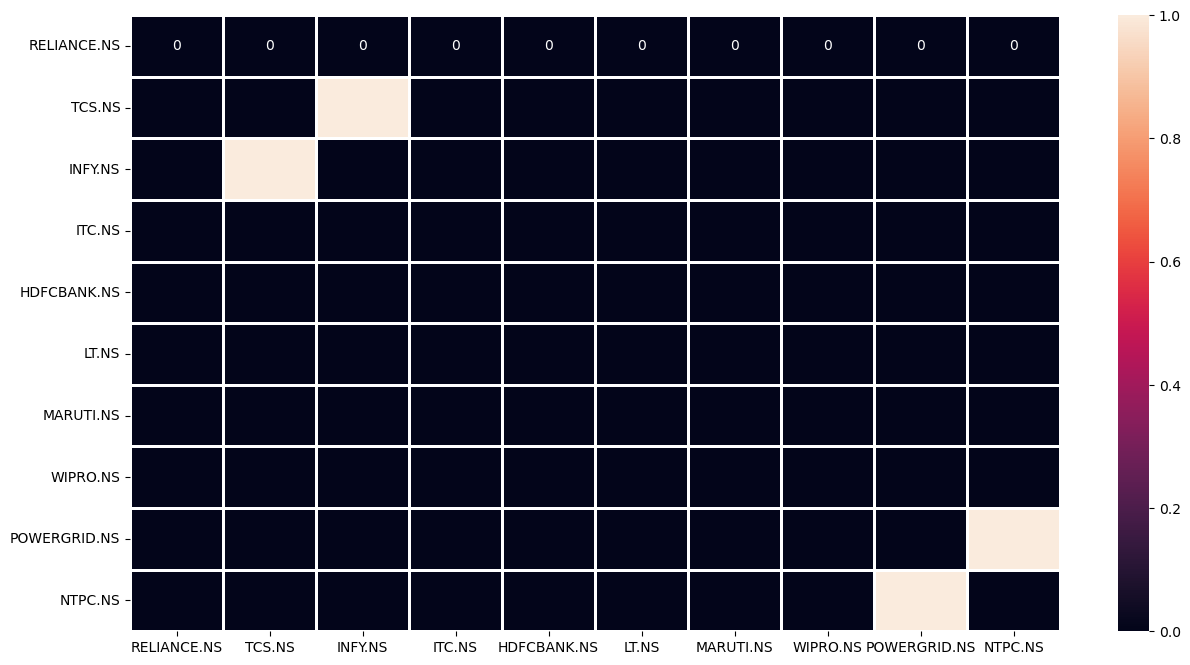

In [33]:
plt.figure(figsize=(15,8))
c = log_returns.corr()
sns.heatmap(((c > 0.68) | (c < -0.68)) & (c != 1),linecolor='white',linewidths=1,annot = True)
plt.show()

- From the heatmaps, we can observe that there is no pair with negative correlation
- We only have some pairs of stocks from banking sector with  high positive correlation

C:\Users\khush\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1507: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\khush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\khush\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1507: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\khush\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\khush\anaconda3\Lib\site-packages\seaborn\axisgrid.py:1507: UserWarning: Ignoring `palette` because no 

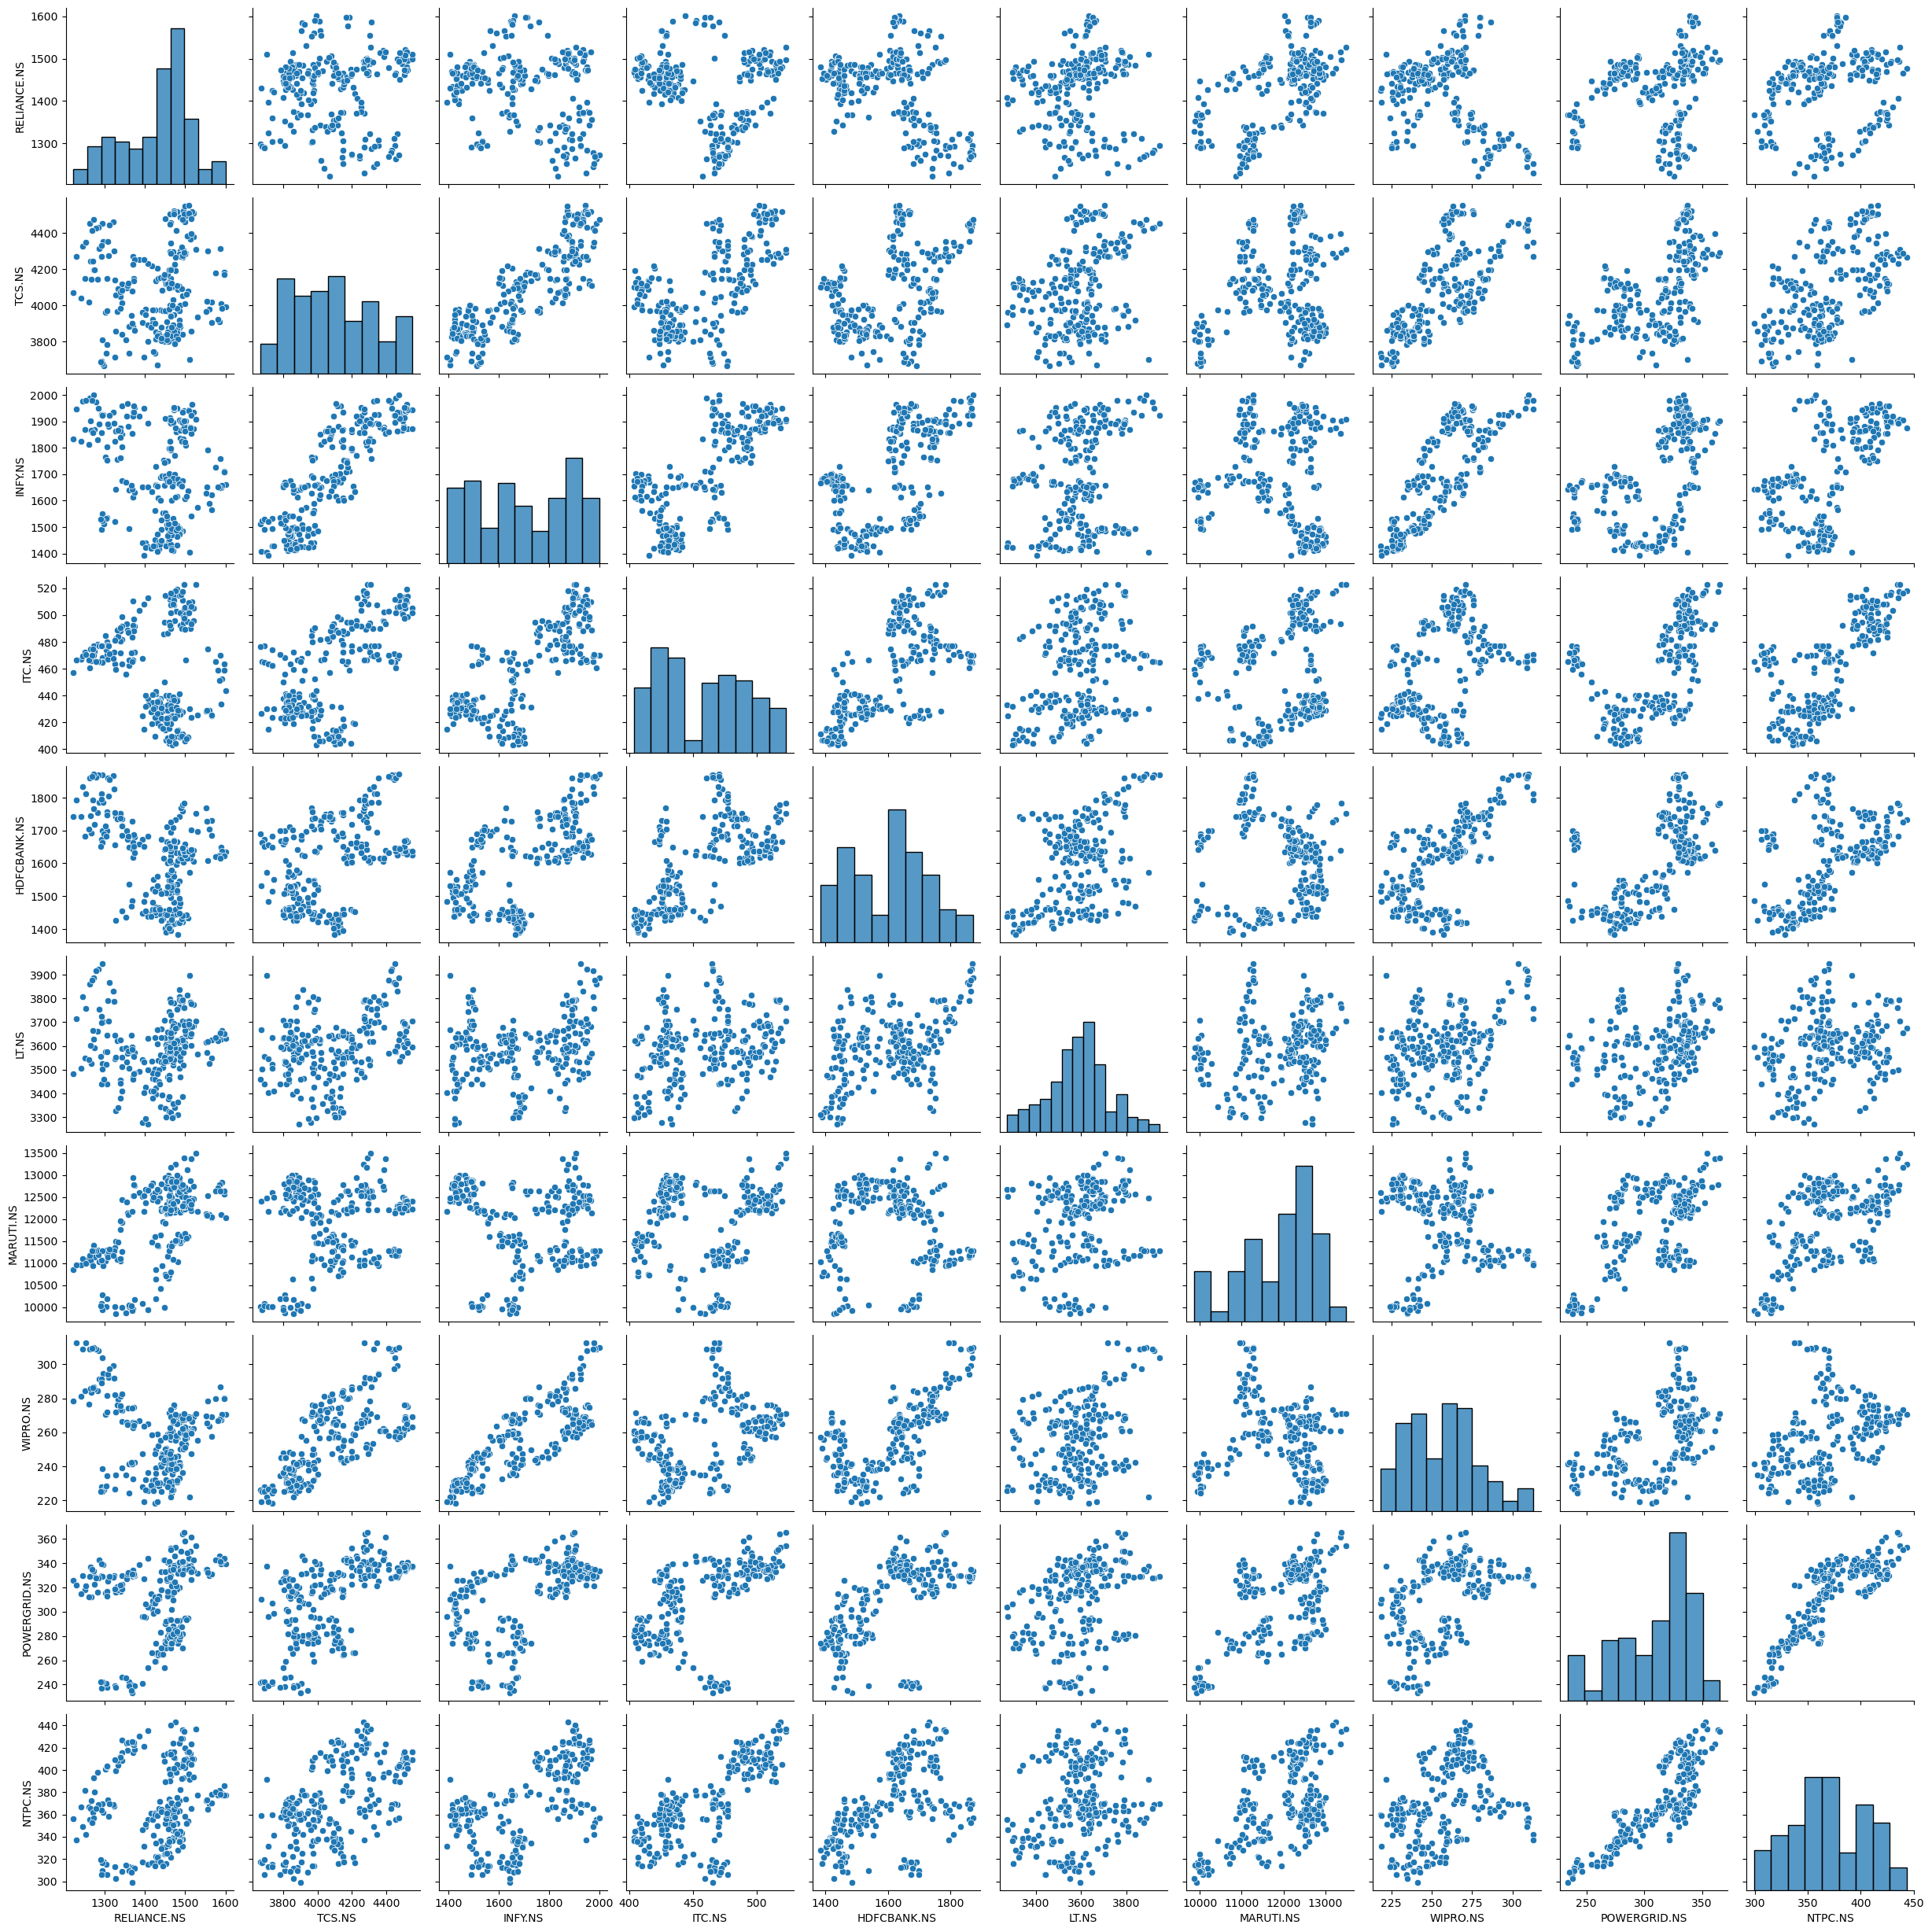

In [34]:
sns.pairplot(pf_data,palette='coolwarm')
plt.show()

- The pair plots also signify the same result that there is no pair of stocks with high negative correlation. We don't find any pair-plot with upper-left to lower-right pattern.
- The pairs with high positive correlation have scatter plot with lower-left to upper-right pattern .
- Other pairs don't form any pattern.

# Markowitz Model







- We model our assets by their expected return, $E[R]$ and their risk, which is expressed as their standard deviation, $\sigma$

- Our investment decisions are expressed by investing 100% of our wealth in assets( here, stocks), where each particular investment represents a proportion of our total wealth. 


- We will now implement Markowitz Model. This model assists in the selection of the most efficient portfolios by analyzing various possible portfolios of the selected stocks.

- We invest $w_i$ in $stock_i$ for every i, such that

 <h1>$$\Sigma^{n}_{i=1} w_i = 1$$</h1>

- The expected return of the portfolio constructed would be

<h1>
$$E[R_p] = \Sigma^{n}_{i=1} w_i E[R_i]$$</h1>

and the risk associated with the portfolio would be


<h1>$$\sigma^2(R_p) = \Sigma^{n}_{i=1} w_i^2 \sigma^2(R_i) + \Sigma^{}_{i=1}\Sigma^{}_{j {\neq} i} w_i w_j \sigma(R_i) \sigma(R_j) \rho_{ij}$$</h1>

$E[R_i]$ is the annual expected return of $i$th stock, $\sigma(R_i)$ corrsponds to annual standard deviation of $i$th stock and $\rho_{ij}$ is the correlation between the logarithmic returns $i$th and the $j$th stock.

- $E[R_p]$ is the annual expected return of the portfolio and $\sigma(R_p)$ is the risk associated with the portfolio (Also the standard deviation of the portfolio)

- An efficient portfolio is one that maximizes return for a given level of risk. Our task is to select adequate weights $w_i$ to get the efficient portfolio

#### Implementation  

-  Let $W_{1 \times n}$ be a array containing the weights $w_i$ such that $\Sigma^{n}_{i=1} w_i = 1$ and $E[R]_{ n\times 1}$ be another array containing annual expected returns of n stocks present in the portfolio and $C$ be the covariance matrix of annual returns of  stocks, then 

$$E[R_p] = WE[R]$$


$$ \sigma^2(R_p) = W^TCW $$

### Sharpe Ratio

- It is a statistical measure used in Modern Portfolio Theory.
- The Sharpe ratio measures the performance of an investment compared to a risk-free asset, after adjusting for its risk. It is defined as the difference between the returns of the investment and the risk-free return, divided by the standard deviation of the investment.
- A portfolio with a higher Sharpe ratio is considered to have best risk-adjusted returns.





$$ S = \frac{E[R_p] - R_f}{\sigma(R_p)} $$

Here, $R_f$ is the risk free rate of return. I have taken risk free rate as 10 year government bond rate of India on December 25th, i.e 4.52%

In [35]:
# A function for generating a numpy array containing random weights that add upto 1
def RandWeights(size):
    weight = np.random.dirichlet(np.ones(size))
    return weight

In [36]:

risk_free_rate = 0.0452 # 4.52% on Dec 25th

# A function to generate the avg return, risk and the sharpe ratio of the portfolio 
# correponding to the weight array passed
def portfolio_stats(weight):

    # Convert to array in case list was passed instead.
    weight = np.array(weight)
    port_return = np.sum(log_returns.mean() * weight) * 250
    port_risk = np.sqrt(np.dot(weight.T, np.dot(log_returns.cov() * 250, weight)))
    sharpe = (port_return - risk_free_rate)/port_risk

    return {'return': port_return, 'risk': port_risk, 'sharpe': sharpe}

In [37]:
# Trying to generate random weights

length = len(log_returns.columns)
weight = RandWeights(length)
weight

array([0.31088537, 0.05201567, 0.00381346, 0.14870486, 0.04106638,
       0.07606327, 0.09076662, 0.15545689, 0.07675323, 0.04447424])

In [38]:
# Generating Portfolio Statistics
pf_stats = portfolio_stats(weight)

pf_return = pf_stats['return']
pf_risk = pf_stats['risk']


In [39]:
pf_return

0.07492187037217904

In [40]:
pf_risk

0.16439345008851428

In [41]:
sharpe_ratio = pf_stats['sharpe']

In [42]:
sharpe_ratio

0.07921161314619095

#### We will now run a monte carlo simulation to generate random portfolios. We will use the results of simulation to draw an efficient frontier

In [43]:
def Monte_Carlo(iterations):
    portfolio_returns = []
    portfolio_risks = []
    for x in range (iterations):
        weight = RandWeights(length)
        pf_stats = portfolio_stats(weight)
        portfolio_returns.append(pf_stats['return'])
        portfolio_risks.append(pf_stats['risk'])
        
    portfolio_returns = np.array(portfolio_returns)
    portfolio_risks = np.array(portfolio_risks)
    return portfolio_returns, portfolio_risks

    

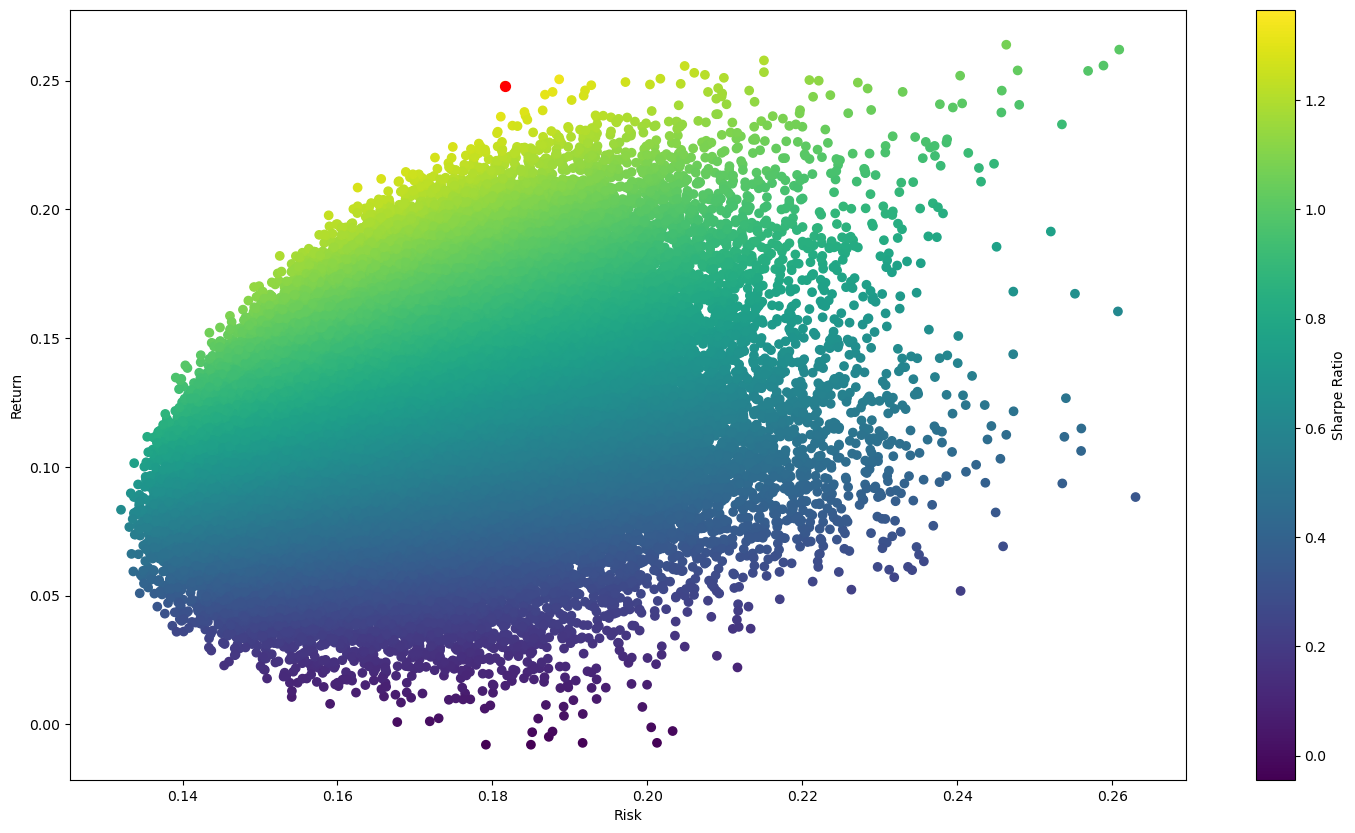

In [44]:
portfolio_returns, portfolio_risks = Monte_Carlo(100000)
sharpe = portfolio_returns / portfolio_risks
max_sr_ret = portfolio_returns[sharpe.argmax()] # return corresponding to maximum sharpe ratio
max_sr_vol = portfolio_risks[sharpe.argmax()] # risk corresponding to maximum sharpe ratio
plt.figure(figsize=(18,10))
plt.scatter(portfolio_risks, portfolio_returns, c=sharpe, cmap='viridis')
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Risk')
plt.ylabel('Return')
plt.scatter(max_sr_vol, max_sr_ret,c='red', s=50) # red dot
plt.show()

- The above plot shows comparison of all portfolio combinations generated in Mone Carlo Simulation in terms of their risk and return. The red dot corresponds to the portfolio having the highest sharpe ratio amoung the generated portfolios. ( This portfolio may not be the one with highest sharpe ratio as we are plotting random portfolios. It is just the portfolio with highest sharpe ratio amoung all the randomly generated portfolios)

- We will now try to generate optimized portffolios subject to various conditions

#### Using Optimization to find portfolio with max sharpe ratio
- The below function returns the weights array cooresponding to the portfolio with the highest Sharpe Ratio
- We are using Scipy.optimize.minimize. We are trying to minimize negative Sharpe Ratio (which is same as maximising the sharpe ratio)
- The constraint for optimization is -> Sum of all the weights has to be 1, and all the weights are bounded between 0 and 1

In [45]:

def OptimizationWithSharpeRatio():

    def FindNegSharpe(weight):
        return (-1)*portfolio_stats(weight)['sharpe']

    res = minimize(
          FindNegSharpe,
          RandWeights(length),
          method = 'SLSQP',
          constraints=[
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.},
          ],
          bounds=[(0., 1.) for i in range(length)]
        )
    
    return res


In [46]:
OptimizationWithSharpeRatio()

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -1.1077087345784087
       x: [ 7.999e-17  1.282e-17  3.581e-01  0.000e+00  0.000e+00
            7.287e-17  0.000e+00  2.581e-01  3.839e-01  2.480e-16]
     nit: 6
     jac: [ 9.402e-01  8.171e-02 -3.148e-01  2.797e-01  1.067e-01
            5.239e-01  6.686e-02 -3.148e-01 -3.148e-01  5.657e-01]
    nfev: 66
    njev: 6

- The optimization is successful. 


- The required weights are in the key x

#### Using Optimisation to find portfolio that has minimum risk for a given expected return

- Sometimes, the investors want to have a portfolio with a fixed targert return. 
- They want to find portfolio that would provide that return with minimum risk involved

In [47]:
def OptimizationForAGivenReturn(target_return):
    
    def fun(weight):
        pf_stats = portfolio_stats(weight)
        _risk = pf_stats['risk']
        return _risk
    
    res = minimize(
      fun,
      RandWeights(length),
      method = 'SLSQP',
      constraints=[{'type':'eq','fun': lambda x: portfolio_stats(x)['return']-target_return},
                   {'type':'eq','fun': lambda x: np.sum(x)-1}],
      bounds=[(0., 1.) for i in range(length)]
    )
    
    return res


In [53]:
OptimizationForAGivenReturn(0.2)

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.1570051663807374
       x: [ 1.407e-17  0.000e+00  3.517e-01  1.065e-01  1.084e-01
            1.624e-17  9.007e-02  1.248e-01  2.185e-01  0.000e+00]
     nit: 11
     jac: [ 1.219e-01  1.261e-01  1.720e-01  7.799e-02  1.015e-01
            1.486e-01  1.049e-01  1.900e-01  2.016e-01  1.754e-01]
    nfev: 121
    njev: 11

- For a return of 20%, we can find the optimal portfolio corresponding to the weights generated above

#### Finding portfolio that provide the minimum risk

In [49]:
def OptimizingWithMinRisk():
    
    def fun(weight):
        pf_stats = portfolio_stats(weight)
        _risk = pf_stats['risk']
        return _risk
        
    
    res = minimize(
      fun,
      RandWeights(length),
      method = 'SLSQP',
      constraints=[
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.},
      ],
      bounds=[(0., 1.) for i in range(length)]
    )

    return res

In [50]:
OptimizingWithMinRisk()

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.13062446416968984
       x: [ 4.927e-02  2.164e-01  8.630e-02  2.869e-01  2.061e-01
            0.000e+00  1.191e-01  0.000e+00  3.591e-02  0.000e+00]
     nit: 7
     jac: [ 1.303e-01  1.303e-01  1.304e-01  1.308e-01  1.309e-01
            1.422e-01  1.305e-01  1.541e-01  1.311e-01  1.496e-01]
    nfev: 77
    njev: 7

### Plotting the efficient Frontier

- The efficient frontier is the set of optimal portfolios that offer the highest expected return for a defined level of risk or the lowest risk for a given level of expected return. Portfolios that lie below the efficient frontier are sub-optimal because they do not provide enough return for the level of risk.





- We will plot the efficient frontier by taking the optimal portfolios for all possible returns

In [51]:
target_returns = np.linspace(portfolio_returns.min(), portfolio_returns.max(),70)

minimal_risks = []
for target_return in target_returns:
    optimal = OptimizationForAGivenReturn(target_return)
    minimal_risks.append(optimal['fun'])

minimal_risks = np.array(minimal_risks)
print(minimal_risks)

[0.1535978  0.15094111 0.14842812 0.14606433 0.14385726 0.14181391
 0.13994159 0.13824743 0.13673768 0.13541862 0.13429597 0.1333748
 0.13265884 0.13213288 0.13170836 0.13137711 0.13113305 0.13094075
 0.13079172 0.1306907  0.13063509 0.13062608 0.13066458 0.13074856
 0.13087874 0.13105549 0.13128016 0.13154663 0.13187163 0.13226685
 0.13273261 0.13326618 0.13386463 0.13451576 0.1352207  0.13597866
 0.13678424 0.13764135 0.13854903 0.13950287 0.14050413 0.14155189
 0.1426455  0.14378258 0.14496292 0.14618563 0.14744923 0.14875276
 0.15009547 0.15147534 0.15289272 0.15434596 0.15583356 0.15735654
 0.15891983 0.16052651 0.16217462 0.1638619  0.16558873 0.16735324
 0.16915391 0.1709906  0.17286039 0.17476482 0.17669924 0.17866531
 0.18066541 0.18271307 0.18481117 0.18695682]


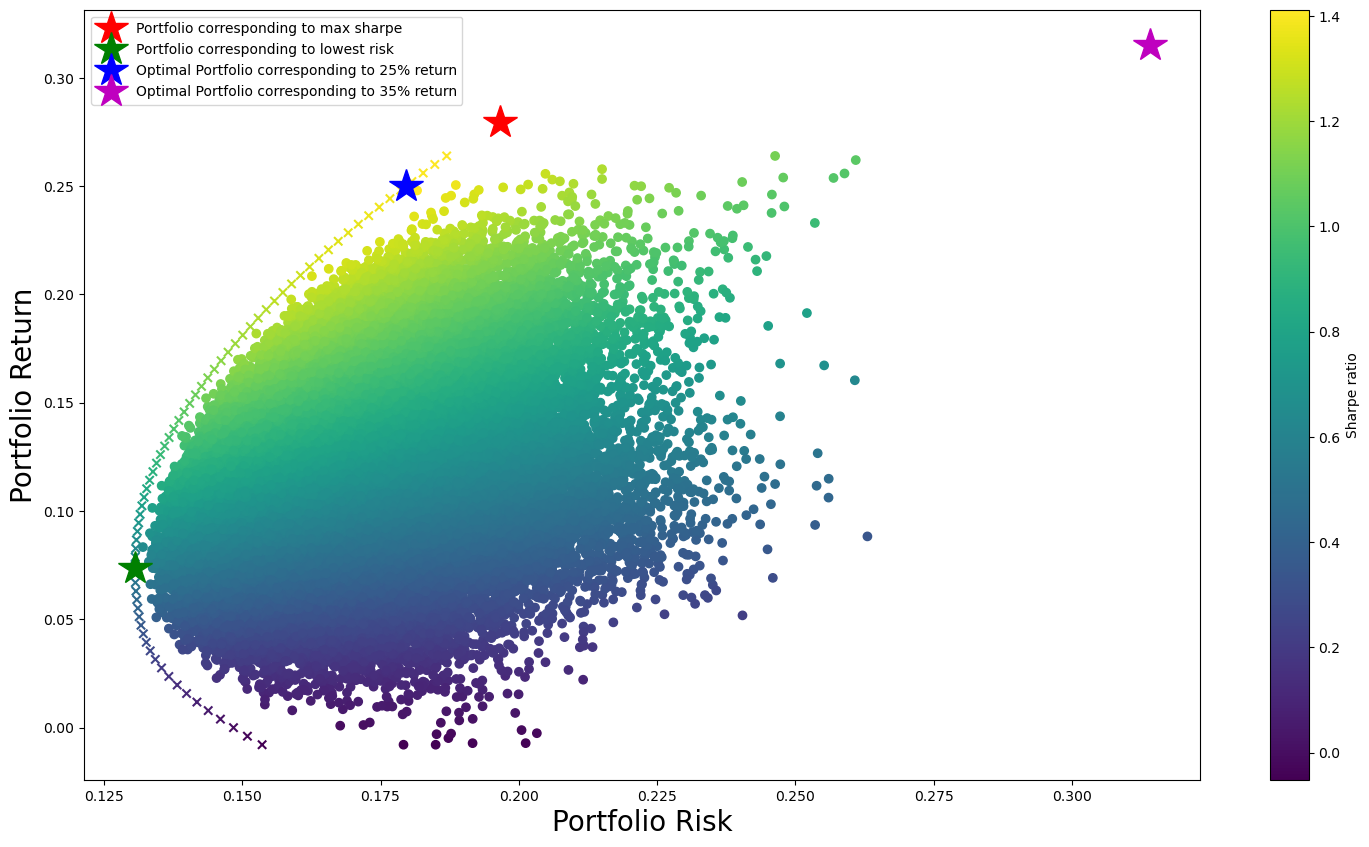

In [52]:
plt.figure(figsize=(18,10))

plt.scatter(portfolio_risks, portfolio_returns,
            c = ( portfolio_returns / portfolio_risks),
            marker = 'o')



# Plotting the efficient frontier
plt.scatter(minimal_risks,
            target_returns,
            c = (target_returns / minimal_risks),
            marker = 'x')


#Plotting the portfolio that has highest Sharpe Ratio
Optimal_weights_For_Highest_Sharpe_Ratio = OptimizationWithSharpeRatio().x

plt.plot(portfolio_stats(Optimal_weights_For_Highest_Sharpe_Ratio)['risk'],
         portfolio_stats(Optimal_weights_For_Highest_Sharpe_Ratio)['return'],
         'r*',
         markersize = 25.0, label = "Portfolio corresponding to max sharpe")



#Plotting the optimal portfolio that has lowest risk
Optimal_weights_For_Lowest_Risk = OptimizingWithMinRisk().x

plt.plot(portfolio_stats(Optimal_weights_For_Lowest_Risk)['risk'],
         portfolio_stats(Optimal_weights_For_Lowest_Risk)['return'],
         'g*',
         markersize = 25.0, label = "Portfolio corresponding to lowest risk")

#Plotting the optimal portfolio for 25% annual returns
Optimal_weights_for_twenty_five_percent_returns = OptimizationForAGivenReturn(0.25).x

plt.plot(portfolio_stats(Optimal_weights_for_twenty_five_percent_returns)['risk'],
         portfolio_stats(Optimal_weights_for_twenty_five_percent_returns)['return'],
         'b*',
         markersize = 25.0, label = "Optimal Portfolio corresponding to 25% return")


#Plotting the optimal portfolio for 35% annual returns
Optimal_weights_for_thirty_five_percent_returns = OptimizationForAGivenReturn(0.35).x

plt.plot(portfolio_stats(Optimal_weights_for_thirty_five_percent_returns)['risk'],
         portfolio_stats(Optimal_weights_for_thirty_five_percent_returns)['return'],
         'm*',
         markersize = 25.0, label = "Optimal Portfolio corresponding to 35% return")

plt.xlabel('Portfolio Risk',fontsize = 20)
plt.ylabel('Portfolio Return', fontsize = 20)
plt.legend(prop={'size': 10})
plt.colorbar(label='Sharpe ratio')

- The efficient frontier is different for different investors, depending upon the assets they are holding



- There is nothing like a single optimal portfolio. The efficient frontier is the collection of optimal portfolios.

- The investors can choose any optimal portfolio depending upon the risk they can take